In [1]:
import csv
import pandas as pd
import numpy as np
import statsmodels.api as sm # For our regression model.
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler # For data normalisation.
import scipy.stats as stats
import matplotlib.dates as mdates

In [2]:
sentiment_by_day_for_avg = pd.read_csv('../Data/Data_Post_Sentiment/sentiment_by_day_for_avg.csv', encoding='utf-8')
sentiment_by_day_for_title = pd.read_csv('../Data/Data_Post_Sentiment/sentiment_by_day_for_title.csv', encoding='utf-8')
sentiment_by_day_for_content = pd.read_csv('../Data/Data_Post_Sentiment/sentiment_by_day_for_content.csv', encoding='utf-8')
All_needed_data = pd.read_csv('../Data/Data_Post_Sentiment/All_needed_data.csv', encoding='utf-8')

In [3]:
All_needed_data

,date,sentiment_mean,sentiment_std,count,brent,wti,vix,ovx,sp500,sentiment_mean_moving_average,...,lagged_vix,lagged_ovx,lagged_sentiment_mean,lagged_sp500,sentiment_mean_abs,brent_percent,wti_percent,vix_percent,ovx_percent,sp500_percent
0,2026-02-28,-0.206794,0.580491,22,72.480003,67.019997,19.860001,64.680000,6878.879883,-0.206794,...,NaN,NaN,NaN,NaN,0.206794,NaN,NaN,NaN,NaN,NaN
1,2026-03-01,-0.191322,0.493140,29,72.480003,67.019997,19.860001,64.680000,6878.879883,-0.199058,...,19.860001,64.680000,-0.206794,6878.879883,0.191322,0.000000,0.000000,0.000000,0.000000,0.000000
2,2026-03-02,-0.378864,0.451896,47,77.369999,73.115002,23.050000,71.420002,6852.989990,-0.258994,...,19.860001,64.680000,-0.191322,6878.879883,0.378864,6.746682,9.094308,16.062434,10.420534,-0.376368
3,2026-03-03,-0.331180,0.578086,35,79.725002,72.895000,24.070000,75.770000,6808.444824,-0.300456,...,23.050000,71.420002,-0.378864,6852.989990,0.331180,3.043820,-0.300898,4.425161,6.090729,-0.650011
4,2026-03-04,-0.328365,0.557129,26,81.650002,74.700001,22.770000,77.064999,6850.594971,-0.346137,...,24.070000,75.770000,-0.331180,6808.444824,0.328365,2.414549,2.476165,-5.400915,1.709117,0.619086
5,2026-03-05,-0.400738,0.518030,25,83.920002,78.580002,22.930000,81.360001,6840.895020,-0.353428,...,22.770000,77.064999,-0.328365,6850.594971,0.400738,2.780160,5.194111,0.702682,5.573220,-0.141593
6,2026-03-06,-0.204718,0.631018,38,88.764999,84.990002,26.345000,98.055000,6754.524902,-0.311274,...,22.930000,81.360001,-0.400738,6840.895020,0.204718,5.773352,8.157292,14.893153,20.519911,-1.262556
7,2026-03-07,-0.025112,0.579793,23,92.690002,90.900002,29.490000,103.599998,6740.020020,-0.210189,...,26.345000,98.055000,-0.204718,6754.524902,0.025112,4.421791,6.953759,11.937747,5.654988,-0.214743
8,2026-03-08,-0.325901,0.512518,33,92.690002,90.900002,29.490000,103.599998,6740.020020,-0.185244,...,29.490000,103.599998,-0.025112,6740.020020,0.325901,0.000000,0.000000,0.000000,0.000000,0.000000
9,2026-03-09,-0.204458,0.503252,54,98.660000,96.384998,30.309999,106.130001,6747.895020,-0.185157,...,29.490000,103.599998,-0.325901,6740.020020,0.204458,6.440821,6.034100,2.780603,2.442087,0.116839


In [4]:
# Regression 1: Basic exploratory regression
# checking is sentiment is persistant, can oil yesterday move sentiment, and does braoder market fear drive sentiement.

reg1 = All_needed_data.copy()
reg1.dropna(inplace=True) # Wont run if null values.

x1 = reg1[['lagged_wti','lagged_vix','lagged_sentiment_mean']] # Our independent variables  If we use lagged_ovx, we introduce alot of multicolinearity as wti (oil) and ovx (oil volatility)
y1 = reg1['sentiment_mean'] # Our dependent variable

x1 = sm.add_constant(x1)
model1 = sm.OLS(y1, x1).fit()
print(model1.summary())

# We expalin 14-20% of the varience in sentiment mean (R^2 vs adj R^2), with our model being jointly significant at the 5% level.
# Both yesterdays wti and vix value are statistically insignificant, thus sentiment does not follow oil and market fear movements day after day.
# Thus news is not just reacting to yesterdays barrel price of oil.

                            OLS Regression Results                            
Dep. Variable:         sentiment_mean   R-squared:                       0.104
Model:                            OLS   Adj. R-squared:                  0.040
Method:                 Least Squares   F-statistic:                     1.630
Date:                Tue, 21 Apr 2026   Prob (F-statistic):              0.197
Time:                        09:52:32   Log-Likelihood:                 16.102
No. Observations:                  46   AIC:                            -24.20
Df Residuals:                      42   BIC:                            -16.89
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                    -0.04

In [ ]:
# Regression 2: Adding dummies and interactive terms.
# 40% explainability with 3 statistically significant variables.

reg2 = All_needed_data.copy()
reg2.dropna(inplace=True) # Wont run if null values.

reg2['disagreement'] = reg2['sentiment_std'] * reg2['count'] # Disagreement around sentiment
reg2['momentum'] = reg2['sentiment_mean'] - reg2['lagged_sentiment_mean'] # Direction

reg2['high_vix_dummy'] = np.where(reg2['vix'] > 25, 1, 0) # Creating a dummy for higher market fear/volatility.


x2 = reg2[['lagged_wti','high_vix_dummy','disagreement','momentum']]
y2 = reg2['sentiment_mean'] # Our dependent variable


x2 = sm.add_constant(x2)
model2 = sm.OLS(y2, x2).fit(cov_type='HC3') #Using HC3 as it is better for smaller samples.
print(model2.summary())


# This model doubles our explainability, at around 50. Overally the model is jointly significant at the 5% level.
# Our dummy is ignificant.
# The disagreement term is significant. Higher disargreement is associated with better mean sentiement, could be as when there is a negative event it is much clearer.
# The momentum term is significant. If sentiment improved yesterday it tends to keep improving today.
# Yesterdays oil still not predictive of todays sentiment.

                            OLS Regression Results                            
Dep. Variable:         sentiment_mean   R-squared:                       0.728
Model:                            OLS   Adj. R-squared:                  0.702
Method:                 Least Squares   F-statistic:                     10.92
Date:                Tue, 21 Apr 2026   Prob (F-statistic):           4.05e-06
Time:                        09:52:32   Log-Likelihood:                 43.550
No. Observations:                  46   AIC:                            -77.10
Df Residuals:                      41   BIC:                            -67.96
Df Model:                           4                                         
Covariance Type:                  HC3                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -0.5156      0.126     -4.

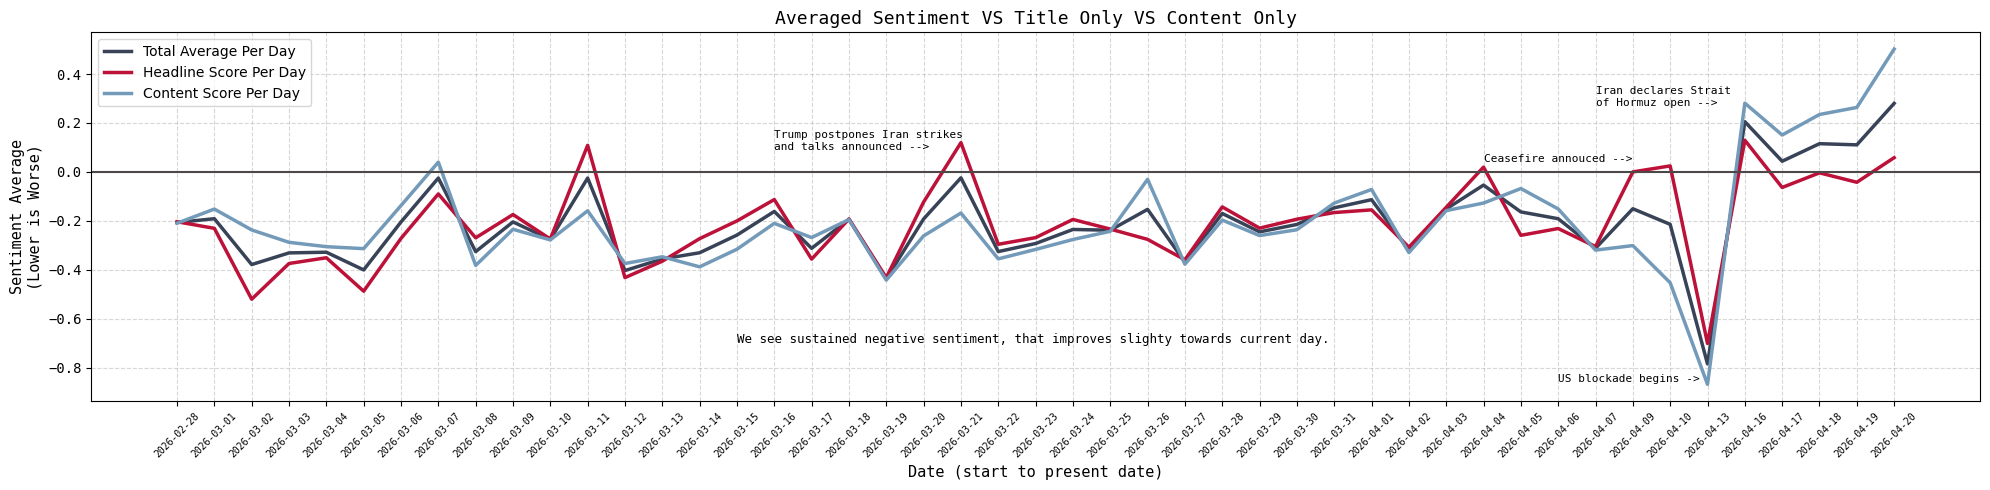

<Figure size 640x480 with 0 Axes>

In [ ]:
# Graph 1: This is a line graph comparing the sentiment scores if we use titles alone, content alone, or the average of them.

fig, ax1 = plt.subplots(figsize=(20, 5))

ax1.plot(sentiment_by_day_for_avg['date'], sentiment_by_day_for_avg['mean'], color='#384358', linewidth=2.5, label='Total Average Per Day')
ax1.plot(sentiment_by_day_for_title['date'], sentiment_by_day_for_title['mean'], color='#BC1139', linewidth=2.5, label='Headline Score Per Day')
ax1.plot(sentiment_by_day_for_content['date'], sentiment_by_day_for_content['mean'], color='#739ab9', linewidth=2.5, label='Content Score Per Day')

ax1.set_ylabel('Sentiment Average\n(Lower is Worse)', fontsize=11, fontfamily='monospace')
ax1.set_xlabel('Date (start to present date)', fontsize=11, fontfamily='monospace')
#ax1.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.SU))
ax1.legend(loc='upper left')
ax1.axhline(0, color="#4D4848")
plt.xticks(rotation=45, fontsize=7, fontfamily='monospace')
plt.yticks(fontfamily='monospace')
plt.grid(linestyle='--', alpha=0.5)

plt.text(sentiment_by_day_for_avg['date'].iloc[15], -0.7, 'We see sustained negative sentiment, that improves slighty towards current day.'
         , color="#000000",fontsize=9,fontfamily='monospace')
plt.text(sentiment_by_day_for_avg['date'].iloc[37], -0.86, 'US blockade begins ->'
         , color="#000000",fontsize=8,fontfamily='monospace')
plt.text(sentiment_by_day_for_avg['date'].iloc[35], 0.04, 'Ceasefire annouced -->'
         , color="#000000",fontsize=8,fontfamily='monospace')
plt.text(sentiment_by_day_for_avg['date'].iloc[38], 0.27, 'Iran declares Strait\nof Hormuz open -->'
         , color="#000000",fontsize=8,fontfamily='monospace')
plt.text(sentiment_by_day_for_avg['date'].iloc[16], 0.09, 'Trump postpones Iran strikes\nand talks announced -->'
         , color="#000000",fontsize=8,fontfamily='monospace')

plt.title('Averaged Sentiment VS Title Only VS Content Only', fontsize=13, fontfamily='monospace')
plt.tight_layout()
plt.show()

plt.savefig('../Outputs/Graphs/Sentiments.png', dpi=300, bbox_inches='tight')

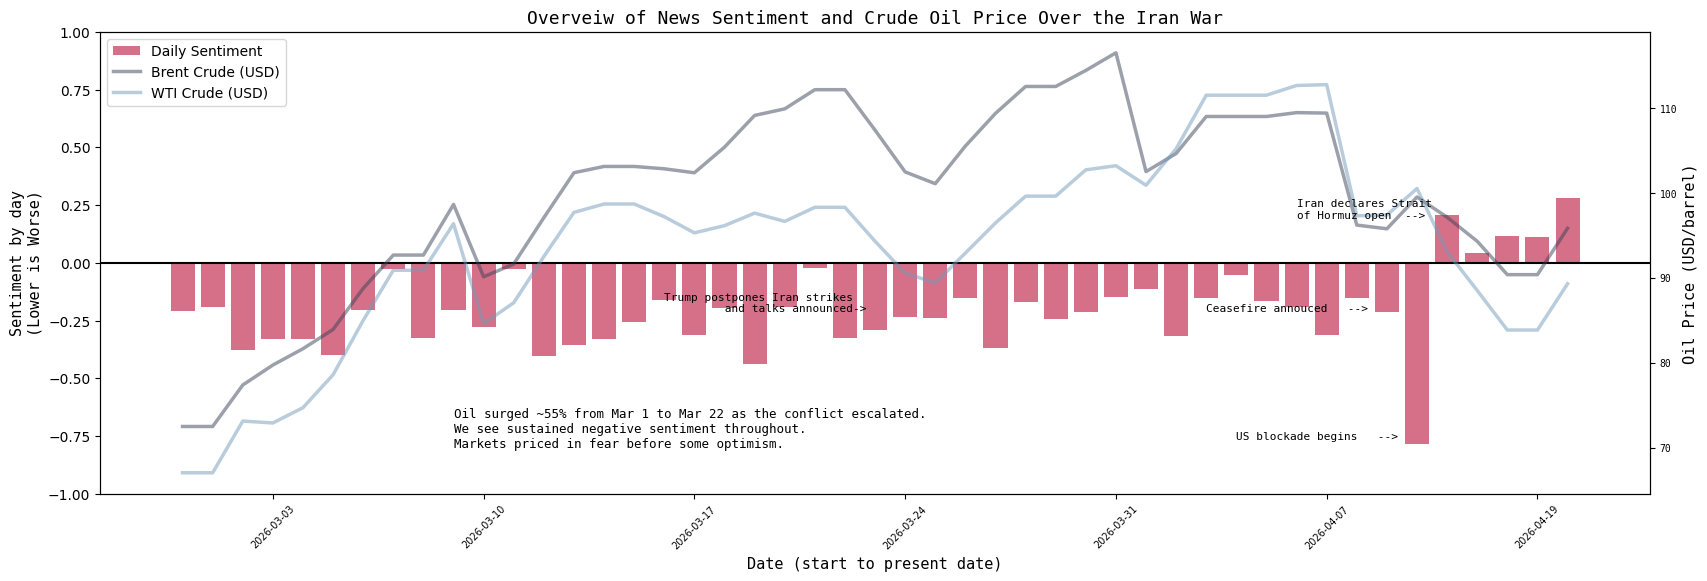

<Figure size 640x480 with 0 Axes>

In [ ]:
# Graph 2: Overview of oil and sentiment.

fig, ax1 = plt.subplots(figsize=(20,6))

ax1.bar(All_needed_data['date'], All_needed_data['sentiment_mean'], color='#BC1139', width=0.8, label='Daily Sentiment',alpha=0.6)
ax1.axhline(0, color='black')
ax1.set_ylabel('Sentiment by day\n(Lower is Worse)', fontsize=11, fontfamily='monospace')
ax1.set_xlabel('Date (start to present date)', fontsize=11, fontfamily='monospace')
ax1.set_ylim(-1, 1)
ax1.tick_params(axis='x', rotation=45, labelsize=7)
ax1.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.SU))

ax2 = ax1.twinx()
ax2.plot(All_needed_data['date'], All_needed_data['brent'], color='#384358', linewidth=2.5, label='Brent Crude (USD)',alpha=0.5)
ax2.plot(All_needed_data['date'], All_needed_data['wti'], color='#739ab9', linewidth=2.5, label='WTI Crude (USD)',alpha=0.5)
ax2.set_ylabel('Oil Price (USD/barrel)', fontsize=11, fontfamily='monospace')
plt.yticks(fontfamily='monospace',fontsize=7)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.text(sentiment_by_day_for_avg['date'].iloc[9], 70, 'Oil surged ~55% from Mar 1 to Mar 22 as the conflict escalated.\nWe see sustained negative sentiment throughout.\nMarkets priced in fear before some optimism.'
         , color="#000000",fontsize=9,fontfamily='monospace')
plt.text(sentiment_by_day_for_avg['date'].iloc[35], 71, 'US blockade begins   -->'
         , color="#000000",fontsize=8,fontfamily='monospace')
plt.text(sentiment_by_day_for_avg['date'].iloc[34], 86, 'Ceasefire annouced   -->'
         , color="#000000",fontsize=8,fontfamily='monospace')
plt.text(sentiment_by_day_for_avg['date'].iloc[37], 97, 'Iran declares Strait\nof Hormuz open  -->'
         , color="#000000",fontsize=8,fontfamily='monospace')
plt.text(sentiment_by_day_for_avg['date'].iloc[16], 86, 'Trump postpones Iran strikes\n         and talks announced->'
         , color="#000000",fontsize=8,fontfamily='monospace')

plt.title('Overveiw of News Sentiment and Crude Oil Price Over the Iran War', fontsize=13, fontfamily='monospace')
plt.show()

plt.savefig('../Outputs/Graphs/Overveiw.png', dpi=300, bbox_inches='tight')

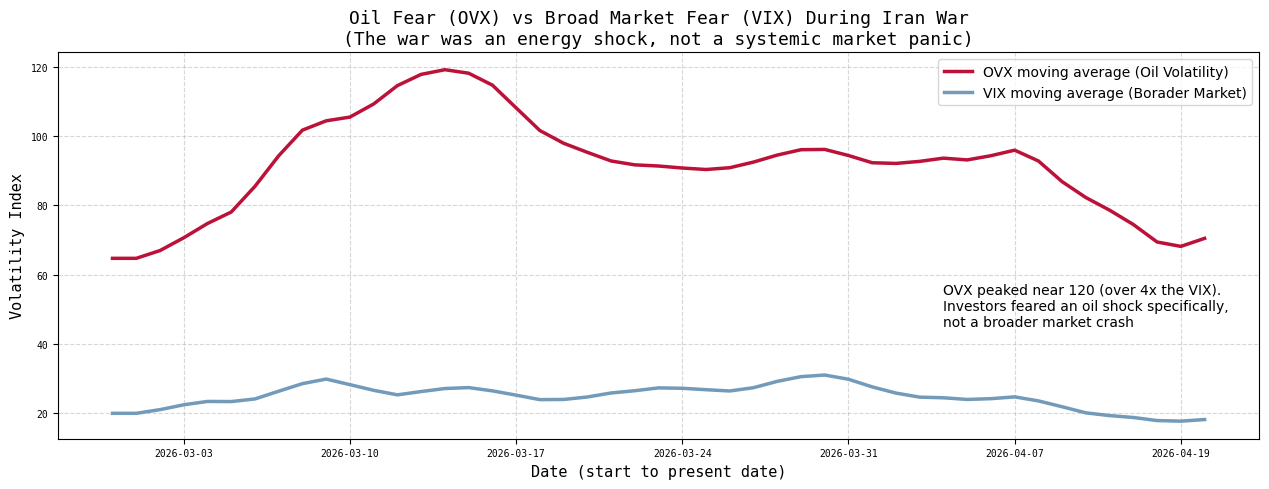

In [152]:
# Graph 3: Comparing oil volatility vs more general market fear.

fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(All_needed_data['date'], All_needed_data['ovx_moving_average'], color='#BC1139', linewidth=2.5, label='OVX moving average (Oil Volatility)')
ax.plot(All_needed_data['date'], All_needed_data['vix_moving_average'], color='#739ab9', linewidth=2.5 , label='VIX moving average (Borader Market)')
ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.SU))
ax.set_ylabel('Volatility Index',fontfamily='monospace',fontsize=11)
ax.set_xlabel('Date (start to present date)', fontsize=11, fontfamily='monospace')
plt.xticks(fontsize=7, fontfamily='monospace')
plt.yticks(fontfamily='monospace',fontsize=7)


plt.text(All_needed_data['date'].iloc[35], 45, 'OVX peaked near 120 (over 4x the VIX).\nInvestors feared an oil shock specifically,\nnot a broader market crash')

plt.grid(linestyle='--', alpha=0.5)
ax.set_title('Oil Fear (OVX) vs Broad Market Fear (VIX) During Iran War\n''(The war was an energy shock, not a systemic market panic)',fontsize=13
             ,fontfamily='monospace')
ax.legend()
plt.tight_layout()

plt.savefig('../Outputs/Graphs/OVX_vs_VIX.png', dpi=300, bbox_inches='tight')

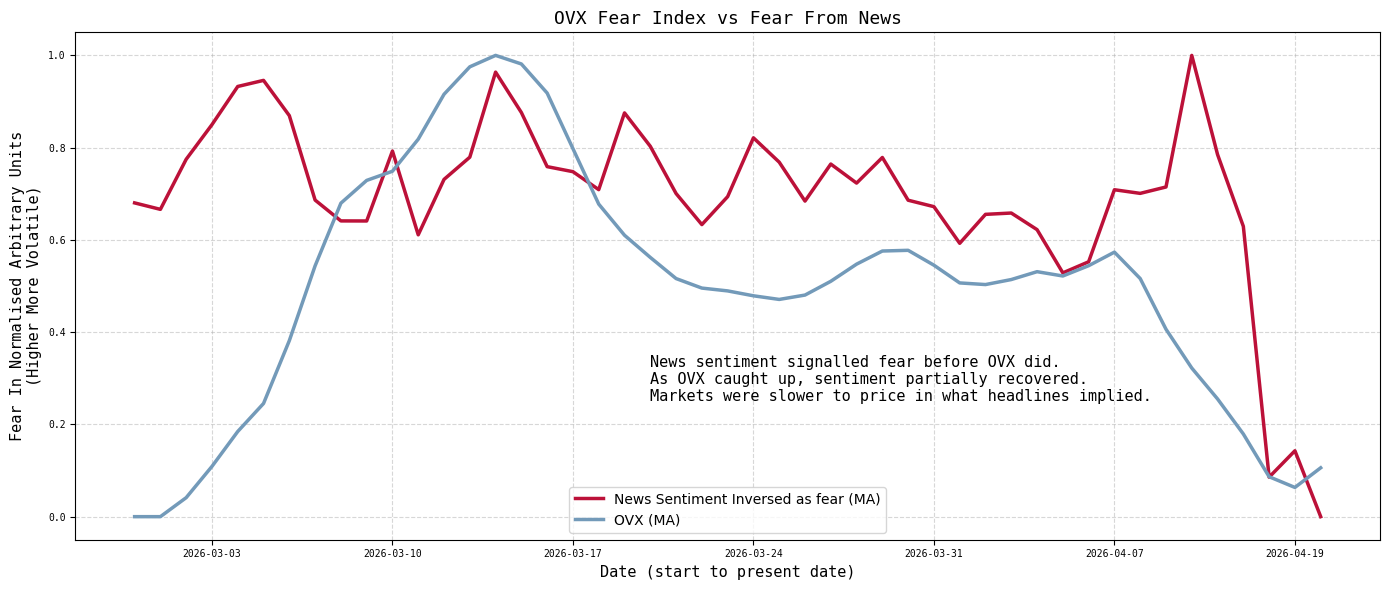

<Figure size 640x480 with 0 Axes>

In [153]:
# Graph 4: We compare the OVX index against our measure of fear.

fig, ax = plt.subplots(figsize=(14, 6))

minmax = All_needed_data[['sentiment_mean_moving_average_inversed','ovx_moving_average']]

scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(minmax.to_numpy())
scaled_data = pd.DataFrame(scaled_data, columns=['scaled_sentiment_mean_moving_average_inversed','scaled_ovx_moving_average'])

ax.plot(All_needed_data['date'], scaled_data['scaled_sentiment_mean_moving_average_inversed'], color='#BC1139', linewidth=2.5, label='News Sentiment Inversed as fear (MA)')
ax.set_ylabel('Fear In Normalised Arbitrary Units\n(Higher More Volatile)', fontsize=11, fontfamily='monospace')
ax.set_xlabel('Date (start to present date)', fontsize=11, fontfamily='monospace')
plt.xticks(fontsize=7, fontfamily='monospace')
plt.yticks(fontfamily='monospace',fontsize=7)
ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.SU))

ax.plot(All_needed_data['date'], scaled_data['scaled_ovx_moving_average'], color='#739ab9', linewidth=2.5, label='OVX (MA)')

ax.legend()


plt.text(All_needed_data['date'].iloc[20], 0.25, f'News sentiment signalled fear before OVX did.\nAs OVX caught up, sentiment partially recovered.\nMarkets were slower to price in what headlines implied.'
         , color="#000000",fontsize=11,fontfamily='monospace')

plt.title('OVX Fear Index vs Fear From News', fontsize=13, fontfamily='monospace')
plt.grid(linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

plt.savefig('../Outputs/Graphs/OVX_vs_news_sentiment.png', dpi=300, bbox_inches='tight')

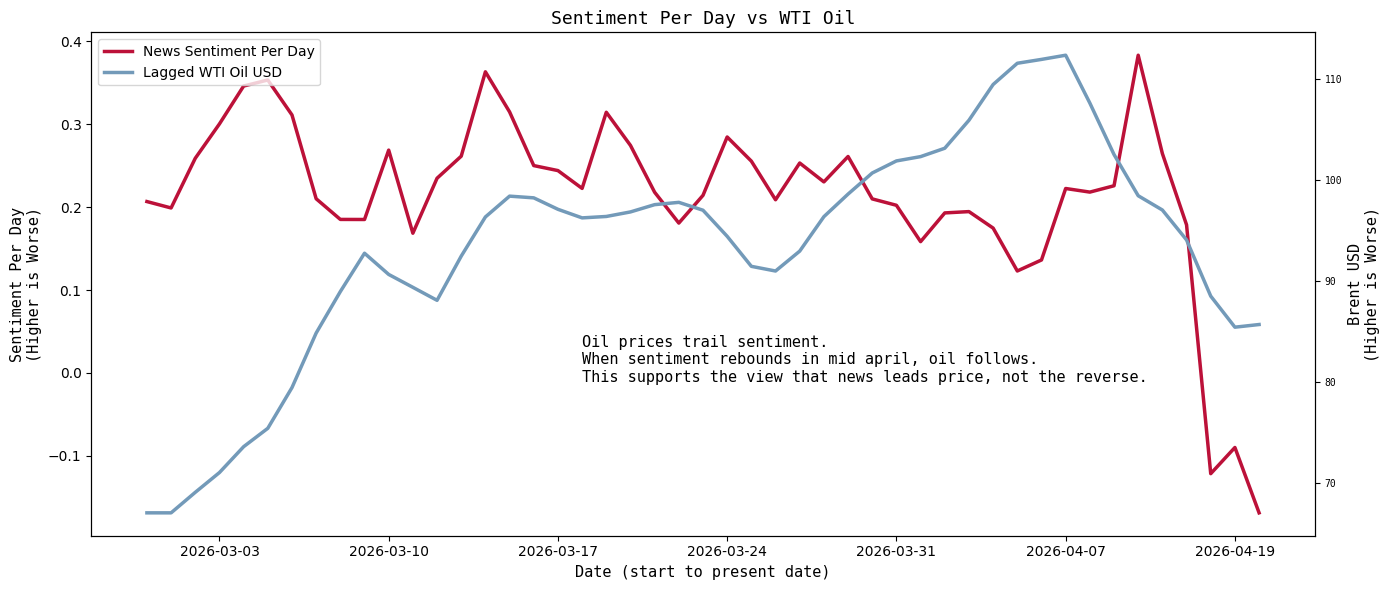

<Figure size 640x480 with 0 Axes>

In [157]:
# Graph 5: Exploring sentiment vs lagged WTI oil.

fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.plot(All_needed_data['date'], All_needed_data['sentiment_mean_moving_average_inversed'], color='#BC1139', linewidth=2.5, label='News Sentiment Per Day')
ax1.set_ylabel('Sentiment Per Day\n(Higher is Worse)', fontsize=11, fontfamily='monospace')
ax1.set_xlabel('Date (start to present date)', fontsize=11, fontfamily='monospace')

ax2 = ax1.twinx()
ax2.plot(All_needed_data['date'], All_needed_data['wti_moving_average'], color='#739ab9', linewidth=2.5, label='Lagged WTI Oil USD')
ax2.set_ylabel('Brent USD\n(Higher is Worse)', fontsize=11, fontfamily='monospace')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
ax1.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.SU))

plt.xticks(fontsize=7, fontfamily='monospace')
plt.yticks(fontfamily='monospace',fontsize=7)

plt.text(All_needed_data['date'].iloc[18], 80, 'Oil prices trail sentiment.\nWhen sentiment rebounds in mid april, oil follows.\nThis supports the view that news leads price, not the reverse.'
         , color="#000000",fontsize=11,fontfamily='monospace')


plt.title('Sentiment Per Day vs WTI Oil', fontsize=13, fontfamily='monospace')
plt.tight_layout()
plt.show()

plt.savefig('../Outputs/Graphs/Sentiment_vs_wti.png', dpi=300, bbox_inches='tight')